In [2]:
from google.colab import drive
drive.mount("/content/drive")
!ls "/content/drive/MyDrive/175/spider_data"

Mounted at /content/drive
database      README.txt     test_gold.sql     train_gold.sql
dev_gold.sql  tables.json    test.json	       train_others.json
dev.json      test_database  test_tables.json  train_spider.json


# Model 1: Baseline

In [21]:
import json
import pandas as pd

path = "/content/drive/MyDrive/175/outputs/t5small_B_updated_preds.jsonl"

df = pd.read_json(path, lines=True)
df.head(10)

,model,db_id,question,gold_sql,pred_sql,prompt_style
0,cssupport/t5-small-awesome-text-to-sql,concert_singer,How many singers do we have?,SELECT count(*) FROM singer,"SELECT COUNT(*) FROM table, singer_in_concert_...",schema_question_sql
1,cssupport/t5-small-awesome-text-to-sql,concert_singer,What is the total number of singers?,SELECT count(*) FROM singer,SELECT COUNT(*) FROM singer_in_concert_ID GROU...,schema_question_sql
2,cssupport/t5-small-awesome-text-to-sql,concert_singer,"Show name, country, age for all singers ordere...","SELECT name , country , age FROM singer ORDE...","SELECT Country, Age FROM singer ORDER BY Age DESC",schema_question_sql
3,cssupport/t5-small-awesome-text-to-sql,concert_singer,"What are the names, countries, and ages for ev...","SELECT name , country , age FROM singer ORDE...","SELECT Name, Country, Age FROM singer ORDER BY...",schema_question_sql
4,cssupport/t5-small-awesome-text-to-sql,concert_singer,"What is the average, minimum, and maximum age ...","SELECT avg(age) , min(age) , max(age) FROM s...","SELECT AVG(Age), MIN(Age), MAX(Age) FROM singe...",schema_question_sql
5,cssupport/t5-small-awesome-text-to-sql,concert_singer,"What is the average, minimum, and maximum age ...","SELECT avg(age) , min(age) , max(age) FROM s...","SELECT AVG(Age), MIN(Age), MAX(Age) FROM singe...",schema_question_sql
6,cssupport/t5-small-awesome-text-to-sql,concert_singer,Show the name and the release year of the song...,"SELECT song_name , song_release_year FROM sin...","SELECT Name, Song_release_year FROM singer ORD...",schema_question_sql
7,cssupport/t5-small-awesome-text-to-sql,concert_singer,What are the names and release years for all t...,"SELECT song_name , song_release_year FROM sin...","SELECT Name, Song_release_year FROM singer ORD...",schema_question_sql
8,cssupport/t5-small-awesome-text-to-sql,concert_singer,What are all distinct countries where singers ...,SELECT DISTINCT country FROM singer WHERE age ...,"SELECT DISTINCT Country, COUNT(*) FROM concert...",schema_question_sql
9,cssupport/t5-small-awesome-text-to-sql,concert_singer,What are the different countries with singers...,SELECT DISTINCT country FROM singer WHERE age ...,"SELECT Country, COUNT(Country) FROM singer WHE...",schema_question_sql


In [23]:
!grep "Execution Accuracy" /content/drive/MyDrive/175/outputs/t5small_B_updated_preds.jsonl

# Model 2: Gemma

We started by evaluating Gemma1-2B-it on the Spider dataset to see its out-of-the-box performance. The highest accuracy achieved by this model during testing was only 13.5%.

Loaded predictions: 1034


100%|██████████| 1034/1034 [00:07<00:00, 130.68it/s]


Execution Accuracy: 0.13539651837524178
Total Errors: 894
error_type
execution_or_syntax_error    80.560928
semantic_error               11.218569
hallucinated_table            4.061896
hallucinated_column           3.481625
aggregation_error             0.386847
join_error                    0.290135
Name: proportion, dtype: float64


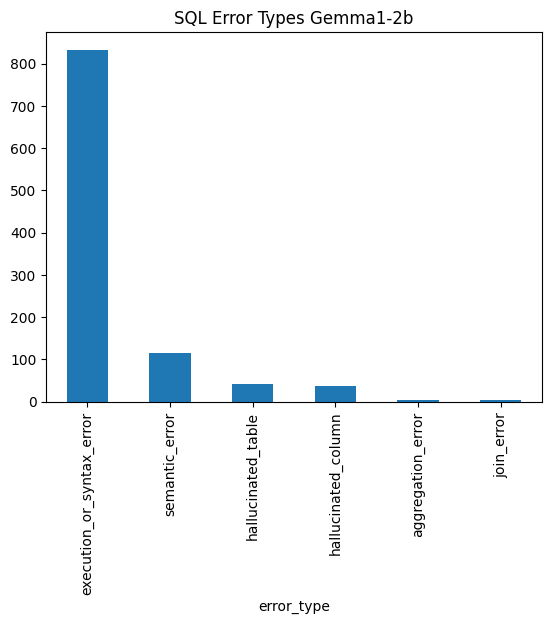

In [24]:
import json
import re
import pandas as pd
import sqlite3
from tqdm import tqdm

# Paths
BASE_PATH = "/content/drive/MyDrive/175/spider_data"
GEMMA2B_PRED_PATH = "/content/drive/MyDrive/175/outputs/gemma2bIT_output.json"

# Load predictions
with open(GEMMA2B_PRED_PATH) as f:
    predictions = json.load(f)

df = pd.DataFrame(predictions)
print("Loaded predictions:", len(df))

# --- Helper Functions ---

def detect_syntax_error(pred_result):
    """Check if execution failed."""
    return pred_result is None

def extract_tables(sql):
    """Extract table names used in SQL."""
    return re.findall(r'FROM\s+(\w+)|JOIN\s+(\w+)', sql, re.IGNORECASE)

def clean_tables(matches):
    tables = []
    for m in matches:
        tables.extend([x for x in m if x])
    return tables

def hallucinated_table(pred_sql, gold_sql):
    pred_tables = set(clean_tables(extract_tables(pred_sql)))
    gold_tables = set(clean_tables(extract_tables(gold_sql)))
    return len(pred_tables - gold_tables) > 0

def extract_columns(sql):
    """Extract columns in format table.column."""
    return re.findall(r'\b\w+\.\w+\b', sql)

def hallucinated_column(pred_sql, gold_sql):
    pred_cols = set(extract_columns(pred_sql))
    gold_cols = set(extract_columns(gold_sql))
    return len(pred_cols - gold_cols) > 0

def aggregation_error(pred_sql, gold_sql):
    aggs = ["count(", "avg(", "sum(", "max(", "min("]
    gold_has_agg = any(x in gold_sql.lower() for x in aggs)
    pred_has_agg = any(x in pred_sql.lower() for x in aggs)
    return gold_has_agg and not pred_has_agg

def join_error(pred_sql, gold_sql):
    gold_has_join = "join" in gold_sql.lower()
    pred_has_join = "join" in pred_sql.lower()
    return gold_has_join and not pred_has_join

def categorize_error(row):
    if row["pred_result"] is None:
        return "execution_or_syntax_error"
    if hallucinated_table(row["predicted_sql"], row["gold_sql"]):
        return "hallucinated_table"
    if hallucinated_column(row["predicted_sql"], row["gold_sql"]):
        return "hallucinated_column"
    if aggregation_error(row["predicted_sql"], row["gold_sql"]):
        return "aggregation_error"
    if join_error(row["predicted_sql"], row["gold_sql"]):
        return "join_error"
    return "semantic_error"

# --- Execute SQL for all predictions ---

def execute_sql(db_id, sql):
    db_path = f"{BASE_PATH}/database/{db_id}/{db_id}.sqlite"
    try:
        conn = sqlite3.connect(db_path)
        cursor = conn.cursor()
        cursor.execute(sql)
        result = cursor.fetchall()
        conn.close()
        return result
    except:
        return None



# Add execution results to dataframe
df["gold_result"] = [execute_sql(row["db_id"], row["gold_sql"]) for idx, row in tqdm(df.iterrows(), total=len(df))]
df["pred_result"] = [execute_sql(row["db_id"], row["predicted_sql"]) for idx, row in tqdm(df.iterrows(), total=len(df))]

df["is_correct"] = df.apply(lambda row: row["pred_result"] == row["gold_result"] and row["gold_result"] is not None, axis=1)

accuracy = df["is_correct"].mean()

print("Execution Accuracy:", accuracy)

gemma_errors = df[df["is_correct"] == False].copy()

print("Total Errors:", len(gemma_errors))

# Categorize errors
df["error_type"] = df.apply(categorize_error, axis=1)

# Error distribution
error_distribution = df["error_type"].value_counts(normalize=True) * 100
print(error_distribution)

# Optional: plot
import matplotlib.pyplot as plt
df["error_type"].value_counts().plot(kind="bar")
plt.title("SQL Error Types Gemma1-2b")
plt.show()

We soon found that, even with careful prompt engineering, this model struggled to generate correct SQL without syntax errors. We then experimented with tuning the model parameters ourselves, but this made little difference—accuracy remained around 15.5%, with syntax errors continuing to account for the majority of failures.

Rather than continuing to tweak Gemma1-2B-it, we opted to try a more powerful model: Gemma3-4B. Even without any modifications, this model produced significantly more accurate SQL. We then added strict prompting and post-processing to ensure that its outputs could be evaluated fairly.


Loaded predictions: 150


100%|██████████| 150/150 [00:01<00:00, 131.11it/s]



Execution Accuracy (Executed Only): 0.76
SQL Failures: 125
Total Errors: 6

Error Distribution:
error_type
execution_or_syntax_error    83.333333
hallucinated_column           8.000000
hallucinated_table            4.666667
semantic_error                4.000000
Name: proportion, dtype: float64


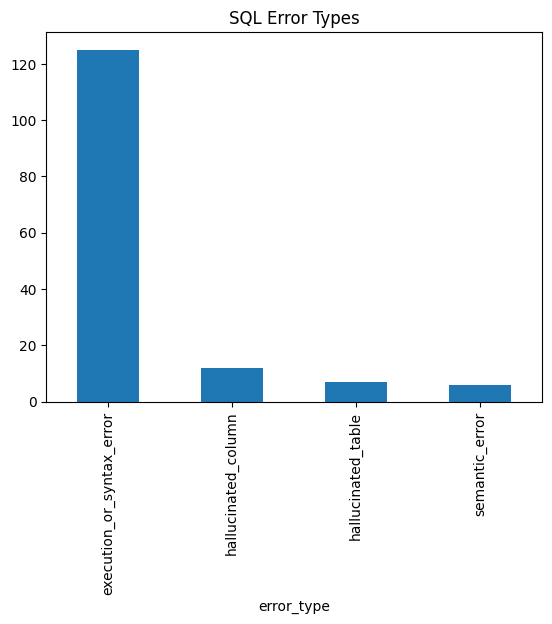

In [25]:
import json
import sqlite3
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

# Paths
BASE_PATH = "/content/drive/MyDrive/175/spider_data"
GEMMA3_4B_PRED_PATH = "/content/drive/MyDrive/175/outputs/gemma3-4bIT_output_clean.json"

# Load predictions
with open(GEMMA3_4B_PRED_PATH) as f:
    predictions = json.load(f)

df = pd.DataFrame(predictions)
print("Loaded predictions:", len(df))

# Execute SQL
def execute_sql(db_id, sql):
    db_path = f"{BASE_PATH}/database/{db_id}/{db_id}.sqlite"
    try:
        conn = sqlite3.connect(db_path)
        cursor = conn.cursor()
        cursor.execute(sql)
        result = cursor.fetchall()
        conn.close()
        return result
    except:
        return None

# Run SQL for gold and predicted queries
df["gold_result"] = [
    execute_sql(row["db_id"], row["gold_sql"])
    for idx, row in tqdm(df.iterrows(), total=len(df))
]

df["pred_result"] = [
    execute_sql(row["db_id"], row["predicted_sql"])
    for idx, row in tqdm(df.iterrows(), total=len(df))
]

# Determine which queries executed successfully
df["executed"] = df["gold_result"].notnull() & df["pred_result"].notnull()


# Compute correctness only for executed queries
df["is_correct"] = (df["pred_result"] == df["gold_result"]) & df["executed"]


# Filter only executed rows for accuracy
executed_df = df[df["executed"]]

accuracy = executed_df["is_correct"].mean()

print("\nExecution Accuracy (Executed Only):", accuracy)
print("SQL Failures:", len(df) - len(executed_df))


# Collect incorrect executed queries for error analysis
gemma_errors = executed_df[executed_df["is_correct"] == False].copy()
print("Total Errors:", len(gemma_errors))


# Categorize errors (assuming categorize_error function exists)
df["error_type"] = df.apply(categorize_error, axis=1)


# Error distribution
error_distribution = df["error_type"].value_counts(normalize=True) * 100
print("\nError Distribution:")
print(error_distribution)


# Plot error distribution
df["error_type"].value_counts().plot(kind="bar")
plt.title("SQL Error Types")
plt.show()

# Model 3: Open AI GPT

We used gpt-4.1-mini model with the following Few-Shot prompt:

> You are an expert SQL generator for SQLite databases. Think step-by-step about which tables and columns are needed. Then write the SQL query. Return ONLY the SQL query. Use valid SQLite syntax.
>
> Example 1
> Schema:
> Table singer(id, name, country)
>
> Question:
> How many singers are from France?
>
> SQL:
> SELECT COUNT(*) FROM singer WHERE country = 'France';
>
> Example 2
> Schema:
> Table student(id, name, age)
>
> Question:
> What is the average age of students?
>
> SQL:
> SELECT AVG(age) FROM student;
>
> Example 3
> Schema:
> Table singer(id, name, country)
> Table concert(id, singer_id, venue)
>
> Question:
> List the names of singers who performed in a concert.
>
> SQL:
> SELECT DISTINCT singer.name
> FROM singer
> JOIN concert ON singer.id = concert.singer_id;
>
> Example 4
> Schema:
> Table student(id, name)
> Table enrollment(student_id, course_id)
> Table course(id, title)
>
> Question:
> List the names of students enrolled in any course.
>
> SQL:
> SELECT DISTINCT student.name
> FROM student
> JOIN enrollment ON student.id = enrollment.student_id
> JOIN course ON enrollment.course_id = course.id;
>
> ---
>
> Schema:
> {schema}
>
> Question:
> {question}
>
> SQL:





In [27]:
import json
import pandas as pd

path = "/content/drive/MyDrive/175/outputs/spider_results_gpt.json"

with open(path, "r") as f:
    results = json.load(f)

df = pd.DataFrame(results)

print("Total examples:", len(df))
df.head()

Total examples: 100


,db_id,question,gold_sql,predicted_sql,gold_result,pred_result,execution_correct
0,concert_singer,How many singers do we have?,SELECT count(*) FROM singer,SELECT COUNT(*) FROM singer;,"([(6,)], None)","([(6,)], None)",True
1,concert_singer,What is the total number of singers?,SELECT count(*) FROM singer,SELECT COUNT(*) FROM singer;,"([(6,)], None)","([(6,)], None)",True
2,concert_singer,"Show name, country, age for all singers ordere...","SELECT name , country , age FROM singer ORDE...","SELECT Name, Country, Age\nFROM singer\nORDER ...","([('Joe Sharp', 'Netherlands', 52), ('John Niz...","([('Joe Sharp', 'Netherlands', 52), ('John Niz...",True
3,concert_singer,"What are the names, countries, and ages for ev...","SELECT name , country , age FROM singer ORDE...","SELECT Name, Country, Age\nFROM singer\nORDER ...","([('Joe Sharp', 'Netherlands', 52), ('John Niz...","([('Joe Sharp', 'Netherlands', 52), ('John Niz...",True
4,concert_singer,"What is the average, minimum, and maximum age ...","SELECT avg(age) , min(age) , max(age) FROM s...","SELECT AVG(Age), MIN(Age), MAX(Age)\nFROM sing...","([(34.5, 25, 43)], None)","([(34.5, 25, 43)], None)",True


In [28]:
accuracy = df["execution_correct"].mean()

print("Execution Accuracy:", accuracy)

gpt_errors = df[df["execution_correct"] == False].copy()

print("Total Errors:", len(gpt_errors))

Execution Accuracy: 0.73
Total Errors: 27


# Error Categoriazation

In [29]:
import re

def extract_tables(sql):
    matches = re.findall(r'FROM\s+(\w+)|JOIN\s+(\w+)', sql, re.IGNORECASE)
    tables = []
    for m in matches:
        tables.extend([x for x in m if x])
    return set(tables)

def extract_columns(sql):
    return set(re.findall(r'\b\w+\.\w+\b', sql))

def categorize_error(row):

    pred_sql = str(row["predicted_sql"]).lower()
    gold_sql = str(row["gold_sql"]).lower()
    pred_result = str(row["pred_result"])

    # execution failure
    if pred_result == "None":
        return "execution_or_syntax_error"

    # hallucinated tables
    pred_tables = extract_tables(pred_sql)
    gold_tables = extract_tables(gold_sql)

    if len(pred_tables - gold_tables) > 0:
        return "hallucinated_table"

    # hallucinated columns
    pred_cols = extract_columns(pred_sql)
    gold_cols = extract_columns(gold_sql)

    if len(pred_cols - gold_cols) > 0:
        return "hallucinated_column"

    # missing join
    if "join" in gold_sql and "join" not in pred_sql:
        return "missing_join"

    # aggregation mismatch
    agg_words = ["count(", "avg(", "sum(", "max(", "min("]

    gold_agg = any(x in gold_sql for x in agg_words)
    pred_agg = any(x in pred_sql for x in agg_words)

    if gold_agg != pred_agg:
        return "aggregation_error"

    return "semantic_error"

In [30]:
# OPEN AI GPT-4.1-MODEL
gpt_errors["error_type"] = gpt_errors.apply(categorize_error, axis=1)
gpt_errors["error_type"].value_counts(normalize=True) * 100

,proportion
error_type,
hallucinated_column,40.740741
semantic_error,33.333333
hallucinated_table,14.814815
missing_join,11.111111


# Mixture of Experts Model

In [8]:
import pandas as pd

results_path = "/content/drive/MyDrive/175/outputs/moe_results.json"

df = pd.read_json(results_path)

print("Total rows:", len(df))

Total rows: 1034


Gemma routed: 58.89748549323017
GPT routed: 41.10251450676983


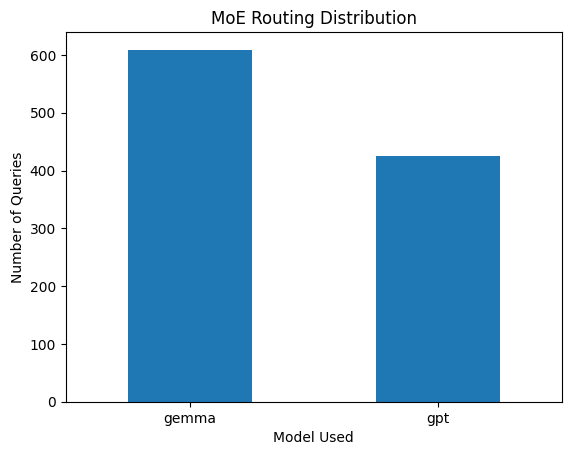

In [9]:
import matplotlib.pyplot as plt

routing_counts = df["source"].value_counts()

gemma_percent = routing_counts["gemma"] / len(df) * 100
gpt_percent = routing_counts["gpt"] / len(df) * 100

print("Gemma routed:", gemma_percent)
print("GPT routed:", gpt_percent)

routing_counts.plot(kind="bar")

plt.title("MoE Routing Distribution")
plt.ylabel("Number of Queries")
plt.xlabel("Model Used")
plt.xticks(rotation=0)

plt.show()

100%|██████████| 1034/1034 [00:29<00:00, 34.77it/s]


Correct: 775
Errors: 259
Accuracy %: 74.95164410058027


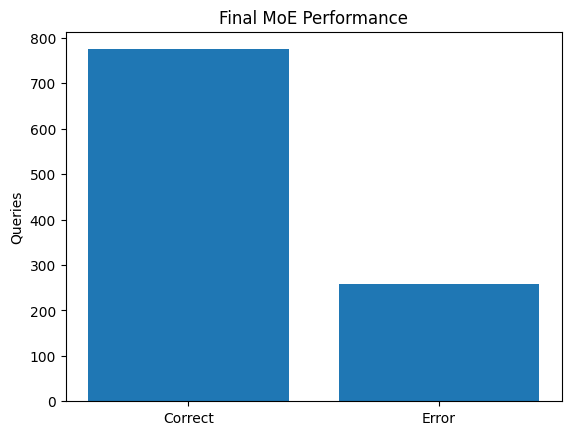

In [20]:
from tqdm import tqdm

# ----------------------------
# RECOMPUTE CORRECTNESS
# ----------------------------
correct = 0
correct_list = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    pred_res = execute_sql(row["db_id"], row["final_sql"])
    gold_res = execute_sql(row["db_id"], row["query"])

    is_correct = pred_res == gold_res
    correct_list.append(is_correct)

    if is_correct:
        correct += 1

# Optional: save correctness in dataframe
df["correct"] = correct_list

# ----------------------------
# CALCULATE ERRORS
# ----------------------------
errors = len(df) - correct
correct_percent = correct / len(df) * 100

print("Correct:", correct)
print("Errors:", errors)
print("Accuracy %:", correct_percent)

# ----------------------------
# PLOT CORRECT VS ERROR
# ----------------------------
labels = ["Correct", "Error"]
values = [correct, errors]

plt.bar(labels, values)
plt.title("Final MoE Performance")
plt.ylabel("Queries")
plt.show()